In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("gemm_sweep_staged_256_rust.csv")

_, mb, nb, kb, avg, _, gflops = df.columns

In [20]:
kb_vals = sorted(df[kb].unique())
data = [df.loc[df[kb] == kb_val, avg].values for kb_val in kb_vals]

/tmp/ipykernel_573492/2996384406.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=kb_vals, showfliers=False)


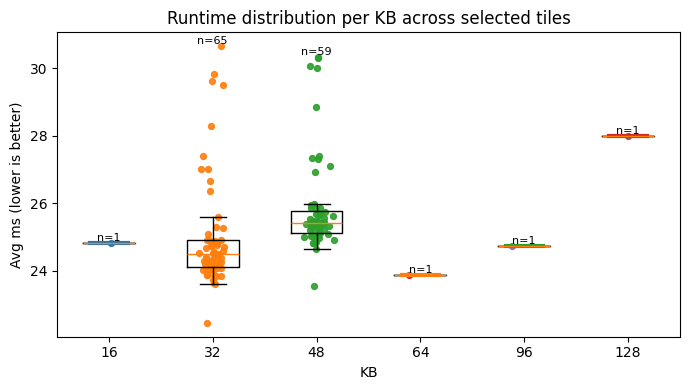

In [21]:
plt.figure(figsize=(7,4))
# 1) boxplot (will collapse to a line when n=1)
plt.boxplot(data, labels=kb_vals, showfliers=False)

for i, g in enumerate(data, start=1):
    if len(g) == 0:
        continue
    # jittered scatter of all points
    x = np.random.normal(loc=i, scale=0.06, size=len(g))
    plt.scatter(x, g, s=18, alpha=0.9)

    # show n per group
    y_top = max(g)
    plt.text(i, y_top, f"n={len(g)}", ha="center", va="bottom", fontsize=8)

    # make singletons obvious (draw a short bold bar)
    if len(g) == 1:
        plt.plot([i-0.18, i+0.18], [g[0], g[0]], linewidth=3)


plt.xlabel("KB")
plt.ylabel("Avg ms (lower is better)")
plt.title("Runtime distribution per KB across selected tiles")
plt.tight_layout()
plt.show()

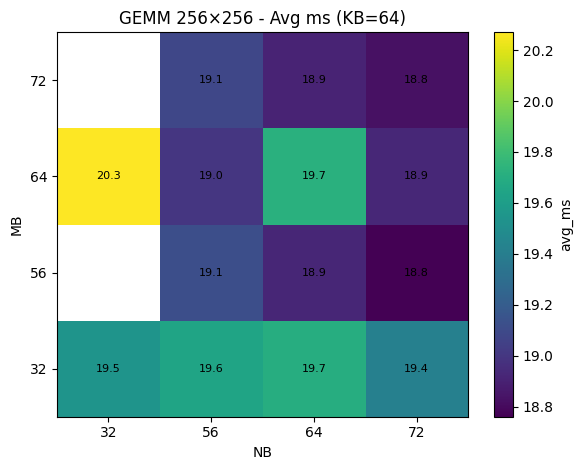

In [ ]:
KB = 32

# using kb, 
MB = [8, 16, 32, 56]
NB = [32, 56, 64, 72]
"""
32	32	32	22.46
8	72	32	23.62
8	64	32	23.63
8	56	32	23.73
16	64	32	23.86
56	64	32	23.87
8	64	32	23.88
16	56	32	23.88
4	72	32	23.89
4	56	32	23.96
4	40	32	24.02
4	48	32	24.04
32	56	32	24.06
16	72	32	24.07
4	64	32	24.08
64	64	32	24.09
8	48	32	24.12
16	48	32	24.13
56	56	32	24.18
64	72	32	24.19
64	64	32	24.21
40	48	32	24.25
64	48	32	24.27
24	56	32	24.27
56	72	32	24.29
8	40	32	24.31
32	48	32	24.35
72	48	32	24.36
8	48	32	24.38
64	48	32	24.39
64	56	32	24.4
72	64	32	24.49
40	40	32	24.5
72	56	32	24.52
16	40	32	24.54
24	48	32	24.54
24	40	32	24.57
72	72	32	24.6
40	56	32	24.69
32	40	32	24.7
32	48	32	24.74
8	32	32	24.78
32	64	32	24.78
32	32	32	24.8
16	64	32	24.83
56	48	32	24.85
48	64	32	24.86
16	32	32	24.87
72	40	32	24.91
56	40	32	24.91
64	32	32	24.92
48	48	32	25.09
64	40	32	25.28
16	48	32	25.31
48	32	32	25.6
64	16	32	26.37
48	16	32	26.65
8	16	32	27.01
16	16	32	27.03
32	16	32	27.4
8	8	32	28.3
16	8	32	29.52
32	8	32	29.62
64	8	32	29.82
48	8	32	30.66
"""
# mb, nb, avg_ms
datapoint = [
    [8, 32, 24.78],
    [8, 56, 23.73],
    [8, 64, 23.63],
    [8, 72, 23.62],
    [16, 32, 24.87],
    [16, 56, 23.88],
    [16, 64, 23.86],
    [16, 72, 24.07],
    [32, 32, 22.46],
    [32, 56, 24.06],
    [32, 64, 24.78],
    [32, 72, np.nan],
    [56, 32, np.nan],
    [56, 56, 24.18],
    [56, 64, 23.87],
    [56, 72, 24.29],
]

# Build DataFrame
df2 = pd.DataFrame(datapoint, columns=["MB", "NB", "avg_ms"])

# Pivot into MB x NB grid and ensure full axes ordering
grid = (
    df2.pivot(index="MB", columns="NB", values="avg_ms")
      .reindex(index=MB, columns=NB)   # keep your desired order
)

data = grid.to_numpy(dtype=float)
masked = np.ma.masked_invalid(data)

# Plot
plt.figure(figsize=(6, 4.8))
im = plt.imshow(masked, origin="lower", aspect="auto")  # no custom colors per your request
plt.xticks(range(len(NB)), NB)
plt.yticks(range(len(MB)), MB)
plt.xlabel("NB")
plt.ylabel("MB")
plt.title(f"GEMM 256×256 - Avg ms (KB={KB})")
plt.colorbar(im, label="avg_ms")

# Annotate only the cells that exist
for i, mb in enumerate(MB):
    for j, nb in enumerate(NB):
        val = grid.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [12]:

import math
import matplotlib.pyplot as plt
import numpy as np

In [13]:
languages = ["Python", "Go", "C++"]
seq = [523.51, 87.34, 65.72] 
openai_par = [np.nan, 13.11, 102.00]
gemini_par = [5485.45, 51.51, 1268.12]

def annotate_bars(ax, xs, ys, fmt="{:.3f}", fontsize=8):
    for x, y in zip(xs, ys):
        ax.text(x, y, fmt.format(y), ha="center", va="bottom", fontsize=fontsize)

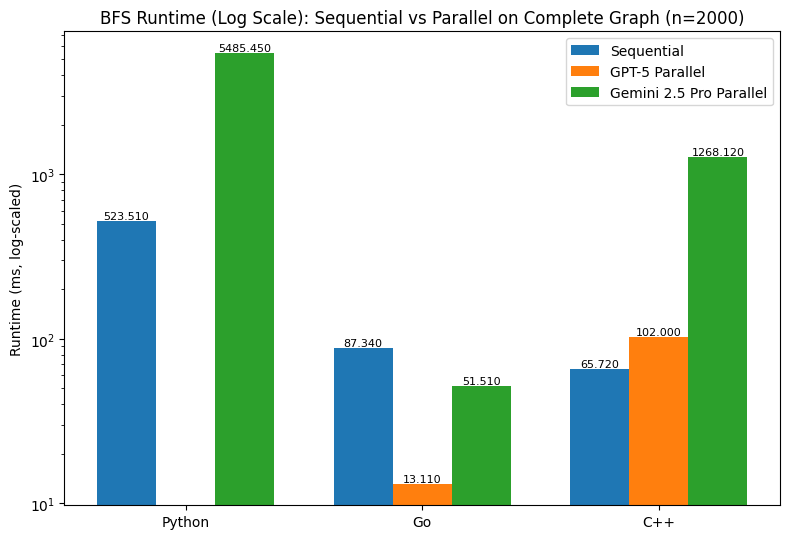

In [14]:
x = list(range(len(languages)))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5.5))
bars_seq_x     = [xi - width for xi in x]
bars_openai_x  = x
bars_gemini_x  = [xi + width for xi in x]

ax.bar(bars_seq_x, seq, width=width, label="Sequential")
ax.bar(bars_openai_x, openai_par, width=width, label="GPT-5 Parallel")
ax.bar(bars_gemini_x, gemini_par, width=width, label="Gemini 2.5 Pro Parallel")

# log scaled
ax.set_yscale("log")
ylabel = "Runtime (ms, log-scaled)"

ax.set_xticks(x, languages)
ax.set_ylabel(ylabel)
ax.set_title("BFS Runtime (Log Scale): Sequential vs Parallel on Complete Graph (n=2000)")
ax.legend()

annotate_bars(ax, bars_seq_x, seq)
annotate_bars(ax, bars_openai_x, openai_par)
annotate_bars(ax, bars_gemini_x, gemini_par)

fig.tight_layout()
plt.show()